# 01 — Exploratory Data Analysis & Data Cleaning

**Project:** Insurance Fraud Detection  
**Dataset:** [Kaggle – Insurance Claims](https://www.kaggle.com/code/meddhiaeddinedabbech/fraud-detection-in-insurance-claims/input?select=insurance_claims.csv)  
**Goal:** Understand the dataset structure, clean the data, and identify features associated with fraudulent claims.

---
## Table of Contents
1. [Setup & Data Import](#1)
2. [Preliminary Analysis & Data Cleaning](#2)
3. [Categorical Variable Analysis](#3)
4. [Numerical Variable Analysis](#4)

## 1. Setup & Data Import <a id='1'></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.set_option('display.max_columns', None)

df = pd.read_csv('../Dataset/insurance_claims.csv')
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

## 2. Preliminary Analysis & Data Cleaning <a id='2'></a>

In [ ]:
df.head(5)

In [ ]:
df.tail(5)

In [ ]:
# Custom info function: extends df.info() with null & unique value counts
def info(df):
    d = df.dtypes
    df_details = pd.DataFrame(data={
        'columns': d.keys(),
        'non_null_values': [df[col].notnull().sum() for col in d.keys()],
        'null_count': [df[col].isnull().sum() for col in d.keys()],
        'types': d.values,
        'unique_values': [df[col].nunique() for col in d.keys()]
    })
    return df_details

infos = info(df)
infos

In [ ]:
# Columns with null or missing values
print("Columns with missing values:")
infos[infos['null_count'] > 0][['columns','null_count','unique_values']]

In [ ]:
# The '?' values used as placeholders for missing data
print("Columns with '?' values:")
for col in df.select_dtypes('object').columns:
    count = (df[col] == '?').sum()
    if count > 0:
        print(f"  {col}: {count} '?' values")

In [ ]:
# Verify: is total_claim_amount always the sum of the three sub claim amounts?
match = (df['total_claim_amount'] == df['injury_claim'] + df['property_claim'] + df['vehicle_claim']).sum()
print(f"{match}/{len(df)} rows where total = injury + property + vehicle")
# -> total_claim_amount is redundant and can be dropped

In [ ]:
mask = (df['authorities_contacted'].isnull()) & (df['police_report_available'] == 'YES')
df.loc[mask, 'authorities_contacted'] = 'Police'

In [ ]:
df[df['authorities_contacted'].isnull()].fraud_reported.value_counts()

In [19]:
# --- Data Cleaning ---

# 1. Handle missing values

# Business Rule : Police report available → Police contacted
mask = (df['authorities_contacted'].isnull()) & (df['police_report_available'] == 'YES')
df.loc[mask, 'authorities_contacted'] = 'Police'

df['authorities_contacted'] = df['authorities_contacted'].fillna('Unknown')

# ~18% null values is an acceptable rate for random imputation
missing_mask = df['collision_type'] == '?'
probs = df['collision_type'].replace('?', np.nan).value_counts(normalize=True)

df.loc[missing_mask, 'collision_type'] = np.random.choice(
    probs.index, size=missing_mask.sum(), p=probs.values
)

# +34% null values is too high for random imputation
df['police_report_available'] = df['police_report_available'].replace('?', 'Unknown')
df['property_damage'] = df['property_damage'].replace('?', 'Unknown')

# 2. Handle weird values
df['umbrella_limit'] = df['umbrella_limit'].replace(-1000000, 0)

# 3. Convert incident_date & policy_bind_date to datetime
df['incident_date'] = pd.to_datetime(df['incident_date'])
df['policy_bind_date'] = pd.to_datetime(df['policy_bind_date'])

# 4. Drop clearly non-informative columns
cols_to_drop = [
    '_c39',              # Completely empty
    'policy_number',     # ID - no predictive value
    'insured_zip',       # Too granular, noisy
    'incident_location', # Free text, too granular
    'total_claim_amount' # Redundant (= sum of sub-claims)
]
df.drop(columns=cols_to_drop, inplace=True)

print(f"Clean dataset: {df.shape[0]} rows, {df.shape[1]} columns")
infos = info(df)
infos

Clean dataset: 1000 rows, 39 columns


,columns,non_null_values,null_count,types,unique_values
0,months_as_customer,1000,0,int64,391
1,age,1000,0,int64,46
2,policy_bind_date,1000,0,datetime64[ns],951
3,policy_state,1000,0,object,3
4,policy_csl,1000,0,object,3
5,policy_deductable,1000,0,int64,3
6,policy_annual_premium,1000,0,float64,991
7,umbrella_limit,1000,0,int64,10
8,insured_sex,1000,0,object,2
9,insured_education_level,1000,0,object,7


## 3. Categorical Variable Analysis <a id='3'></a>

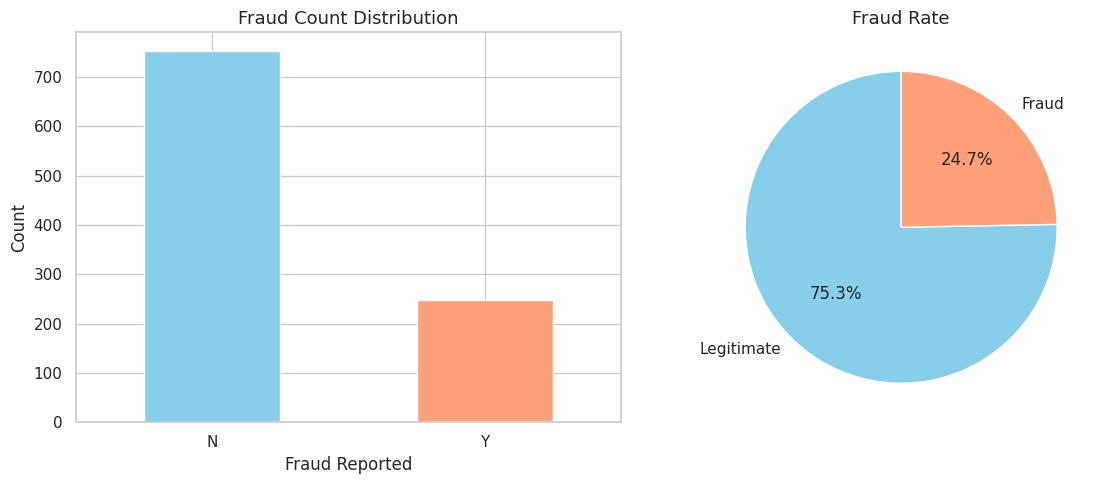

fraud_reported_bin
0    753
1    247
Name: count, dtype: int64


In [20]:
# Target variable distribution
df['fraud_reported_bin'] = (df['fraud_reported'] == 'Y').astype(int)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

df['fraud_reported'].value_counts().plot.bar(ax=axs[0], color=['skyblue','lightsalmon'], edgecolor='white')
axs[0].set_title('Fraud Count Distribution', fontsize=13)
axs[0].set_xlabel('Fraud Reported')
axs[0].set_ylabel('Count')
axs[0].tick_params(axis='x', rotation=0)

df['fraud_reported'].value_counts().plot.pie(
    ax=axs[1], autopct='%1.1f%%', colors=['skyblue','lightsalmon'],
    startangle=90, labels=['Legitimate','Fraud']
)
axs[1].set_ylabel('')
axs[1].set_title('Fraud Rate', fontsize=13)

plt.tight_layout()
plt.show()
print(df['fraud_reported_bin'].value_counts())

**Observations**
- A ~25% fraud rate is consistent with industry benchmarks (12-30% fraud rate).
- The dataset is moderately imbalanced: ~25% fraudulent claims, ~75% legitimate.
- Class imbalance should be addressed during modelling (SMOTE, class_weight).

In [21]:
# Group high-cardinality categoricals into meaningful buckets
def group_hobby(hobby):
    high_risk = ['bungie-jumping', 'base-jumping', 'skydiving', 'paintball']
    active = ['exercise', 'cross-fit', 'basketball', 'golf', 'hiking', 'polo', 'camping', 'kayaking', 'yoga']
    if hobby in high_risk:
        return 'high_risk'
    elif hobby in active:
        return 'active'
    else:
        return 'leisure'

def group_occupation(occ):
    white_collar = ['exec-managerial', 'prof-specialty', 'tech-support', 'adm-clerical', 'protective-serv', 'sales']
    blue_collar = ['craft-repair', 'machine-op-inspct', 'transport-moving', 'handlers-cleaners', 'farming-fishing', 'priv-house-serv']
    if occ in white_collar:
        return 'white_collar'
    elif occ in blue_collar:
        return 'blue_collar'
    else:
        return 'other'

def group_auto_make(make):
    luxury = ['Mercedes', 'BMW', 'Audi', 'Porsche', 'Lexus', 'Jeep', 'Land Rover', 'Suburu']
    if make in luxury:
        return 'luxury'
    return 'mainstream'

df['hobby_group'] = df['insured_hobbies'].apply(group_hobby)
df['occupation_group'] = df['insured_occupation'].apply(group_occupation)
df['auto_make_group'] = df['auto_make'].apply(group_auto_make)
print("Grouping complete")

Grouping complete


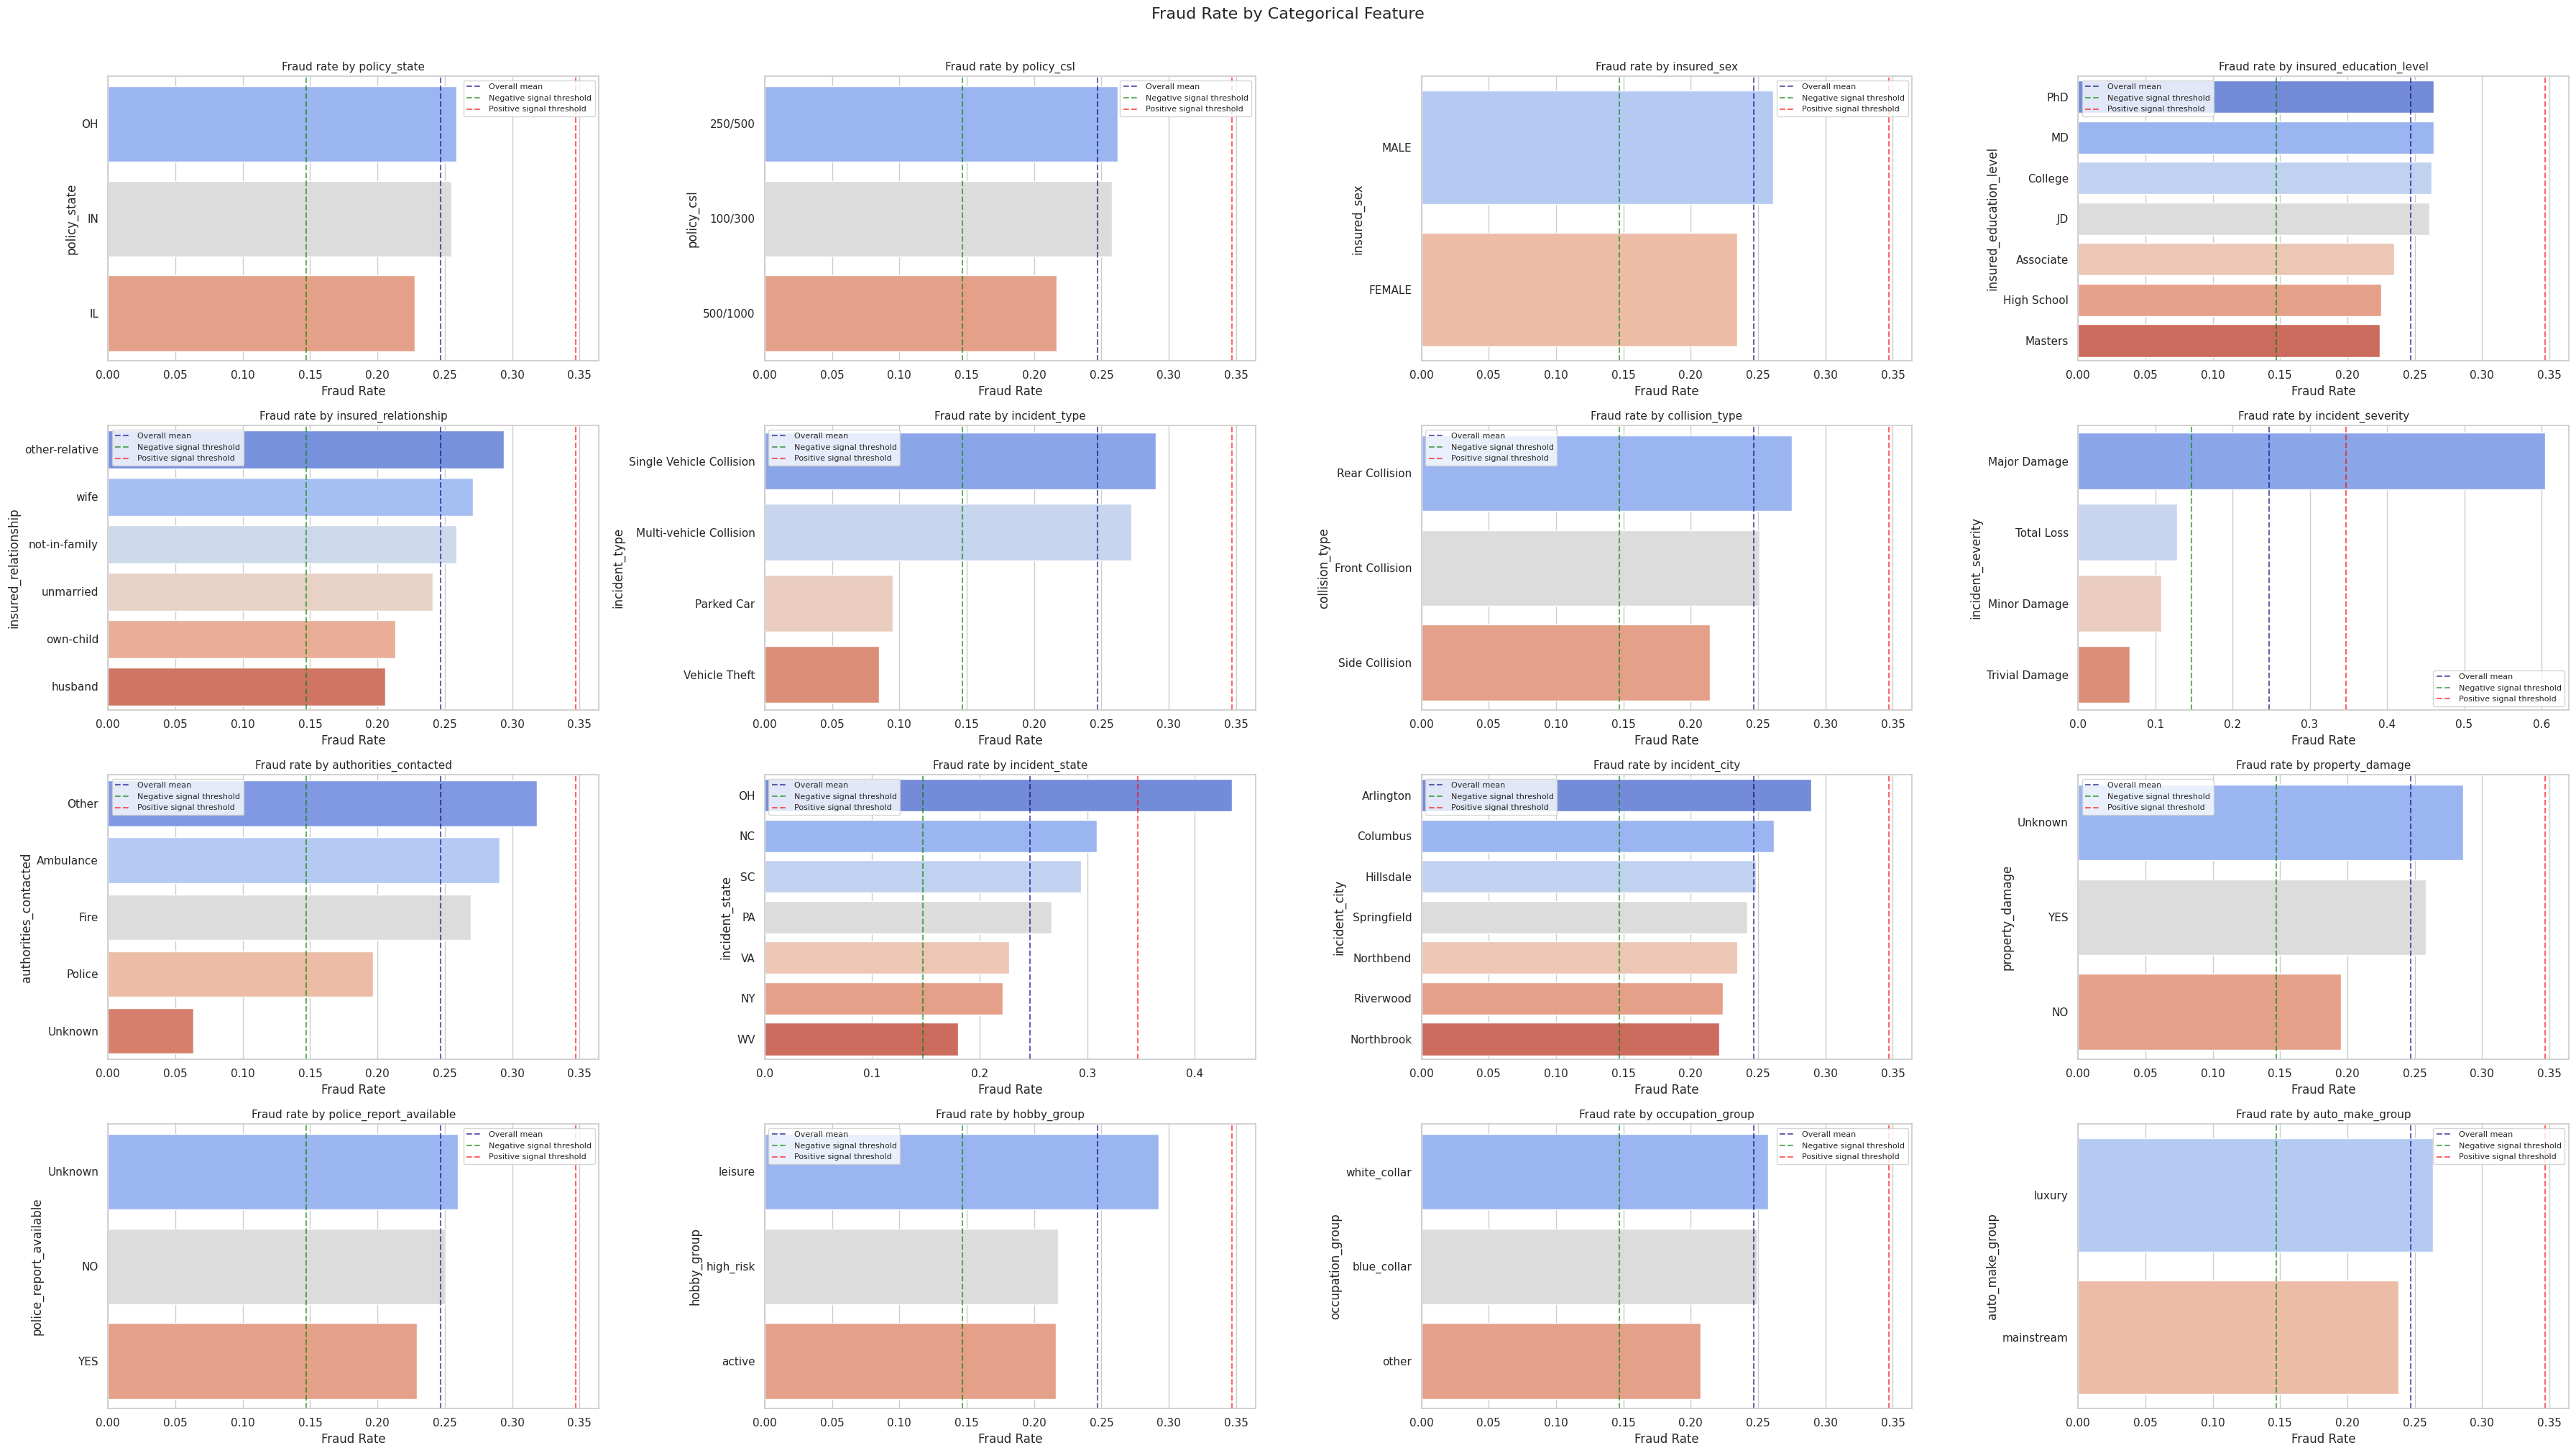

In [22]:
# Fraud rate across all low-cardinality categorical features
cat_cols = info(df)[
    (info(df)['unique_values'] <= 8) &
    (info(df)['types'] == 'object') &
    (info(df)['columns'] != 'fraud_reported')
]['columns'].tolist()
cat_cols += ['hobby_group', 'occupation_group', 'auto_make_group']
cat_cols = list(dict.fromkeys(cat_cols))

n = len(cat_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axs = plt.subplots(nrows, ncols, figsize=(36, nrows * 5))
axs = axs.flatten()

for i, col in enumerate(cat_cols):
    fraud_rate = df.groupby(col)['fraud_reported_bin'].mean().sort_values(ascending=False)
    sns.barplot(x=fraud_rate.values, y=fraud_rate.index, ax=axs[i], palette='coolwarm', hue=fraud_rate.index)
    axs[i].set_title(f'Fraud rate by {col}', fontsize=11)
    axs[i].set_xlabel('Fraud Rate')
    axs[i].axvline(df['fraud_reported_bin'].mean(), color='navy', linestyle='--', alpha=0.6, label='Overall mean')
    axs[i].axvline(df['fraud_reported_bin'].mean()-0.1, color='green', linestyle='--', alpha=0.6, label='Negative signal threshold')
    axs[i].axvline(df['fraud_reported_bin'].mean()+0.1, color='red', linestyle='--', alpha=0.6, label='Positive signal threshold')
    axs[i].legend(fontsize=8)

for j in range(i + 1, len(axs)):
    axs[j].set_visible(False)

plt.suptitle('Fraud Rate by Categorical Feature', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

In [23]:
# Detailed crosstabs for the most discriminating categorical features
key_cats = [
    'incident_type', 'incident_severity', 'incident_state',
    'authorities_contacted', 'property_damage', 'hobby_group',
]
for col in key_cats:
    ct = pd.crosstab(df[col], df['fraud_reported_bin'], normalize='index').round(3)
    ct.columns = ['Legitimate', 'Fraud']
    ct['Total_count'] = df[col].value_counts()
    print(f"\n--- {col} ---")
    print(ct.sort_values('Fraud', ascending=False))


--- incident_type ---
                          Legitimate  Fraud  Total_count
incident_type                                           
Single Vehicle Collision       0.710  0.290          403
Multi-vehicle Collision        0.728  0.272          419
Parked Car                     0.905  0.095           84
Vehicle Theft                  0.915  0.085           94

--- incident_severity ---
                   Legitimate  Fraud  Total_count
incident_severity                                
Major Damage            0.395  0.605          276
Total Loss              0.871  0.129          280
Minor Damage            0.893  0.107          354
Trivial Damage          0.933  0.067           90

--- incident_state ---
                Legitimate  Fraud  Total_count
incident_state                                
OH                   0.565  0.435           23
NC                   0.691  0.309          110
SC                   0.706  0.294          248
PA                   0.733  0.267           30
VA

**Observations - Categorical Variables**

| Feature | Insight | Status |
|---|---|---|
| `incident_severity` | Major Damage: ~60% fraud rate (35pts above baseline) | Strong |
| `incident_type` | Parked Car/Vehicle Theft: ~9% fraud rate (16pts below baseline) | Strong |
| `authorities_contacted` | Other: ~32% (suspicious to avoid police) | Moderate |
| `property_damage` | ~9pts spread | Borderline |
| `hobby_group` | ~8pts spread | Borderline |
| `incident_state` | OH: 43% fraud but count=23 makes it statistically fragile | Weak |


## 4. Numerical Variable Analysis <a id='4'></a>

In [24]:
# Overview of numerical features
num_infos = info(df)[info(df)['types'] != 'object']
print(f"{len(num_infos)} numerical columns:")
num_infos

18 numerical columns:


,columns,non_null_values,null_count,types,unique_values
0,months_as_customer,1000,0,int64,391
1,age,1000,0,int64,46
2,policy_bind_date,1000,0,datetime64[ns],951
5,policy_deductable,1000,0,int64,3
6,policy_annual_premium,1000,0,float64,991
7,umbrella_limit,1000,0,int64,10
13,capital-gains,1000,0,int64,338
14,capital-loss,1000,0,int64,354
15,incident_date,1000,0,datetime64[ns],60
22,incident_hour_of_the_day,1000,0,int64,24


In [25]:
# Statistical summary
df[num_infos['columns'].tolist()].describe().T

,count,mean,min,25%,50%,75%,max,std
months_as_customer,1000.0,203.954,0.0,115.75,199.5,276.25,479.0,115.113174
age,1000.0,38.948,19.0,32.0,38.0,44.0,64.0,9.140287
policy_bind_date,1000,2002-02-08 04:40:47.999999872,1990-01-08 00:00:00,1995-09-19 00:00:00,2002-04-01 12:00:00,2008-04-21 12:00:00,2015-02-22 00:00:00,NaN
policy_deductable,1000.0,1136.0,500.0,500.0,1000.0,2000.0,2000.0,611.864673
policy_annual_premium,1000.0,1256.40615,433.33,1089.6075,1257.2,1415.695,2047.59,244.167395
umbrella_limit,1000.0,1102000.0,0.0,0.0,0.0,0.0,10000000.0,2296708.703965
capital-gains,1000.0,25126.1,0.0,0.0,0.0,51025.0,100500.0,27872.187708
capital-loss,1000.0,-26793.7,-111100.0,-51500.0,-23250.0,0.0,0.0,28104.096686
incident_date,1000,2015-01-30 08:02:24,2015-01-01 00:00:00,2015-01-15 00:00:00,2015-01-31 00:00:00,2015-02-15 00:00:00,2015-03-01 00:00:00,NaN
incident_hour_of_the_day,1000.0,11.644,0.0,6.0,12.0,17.0,23.0,6.951373


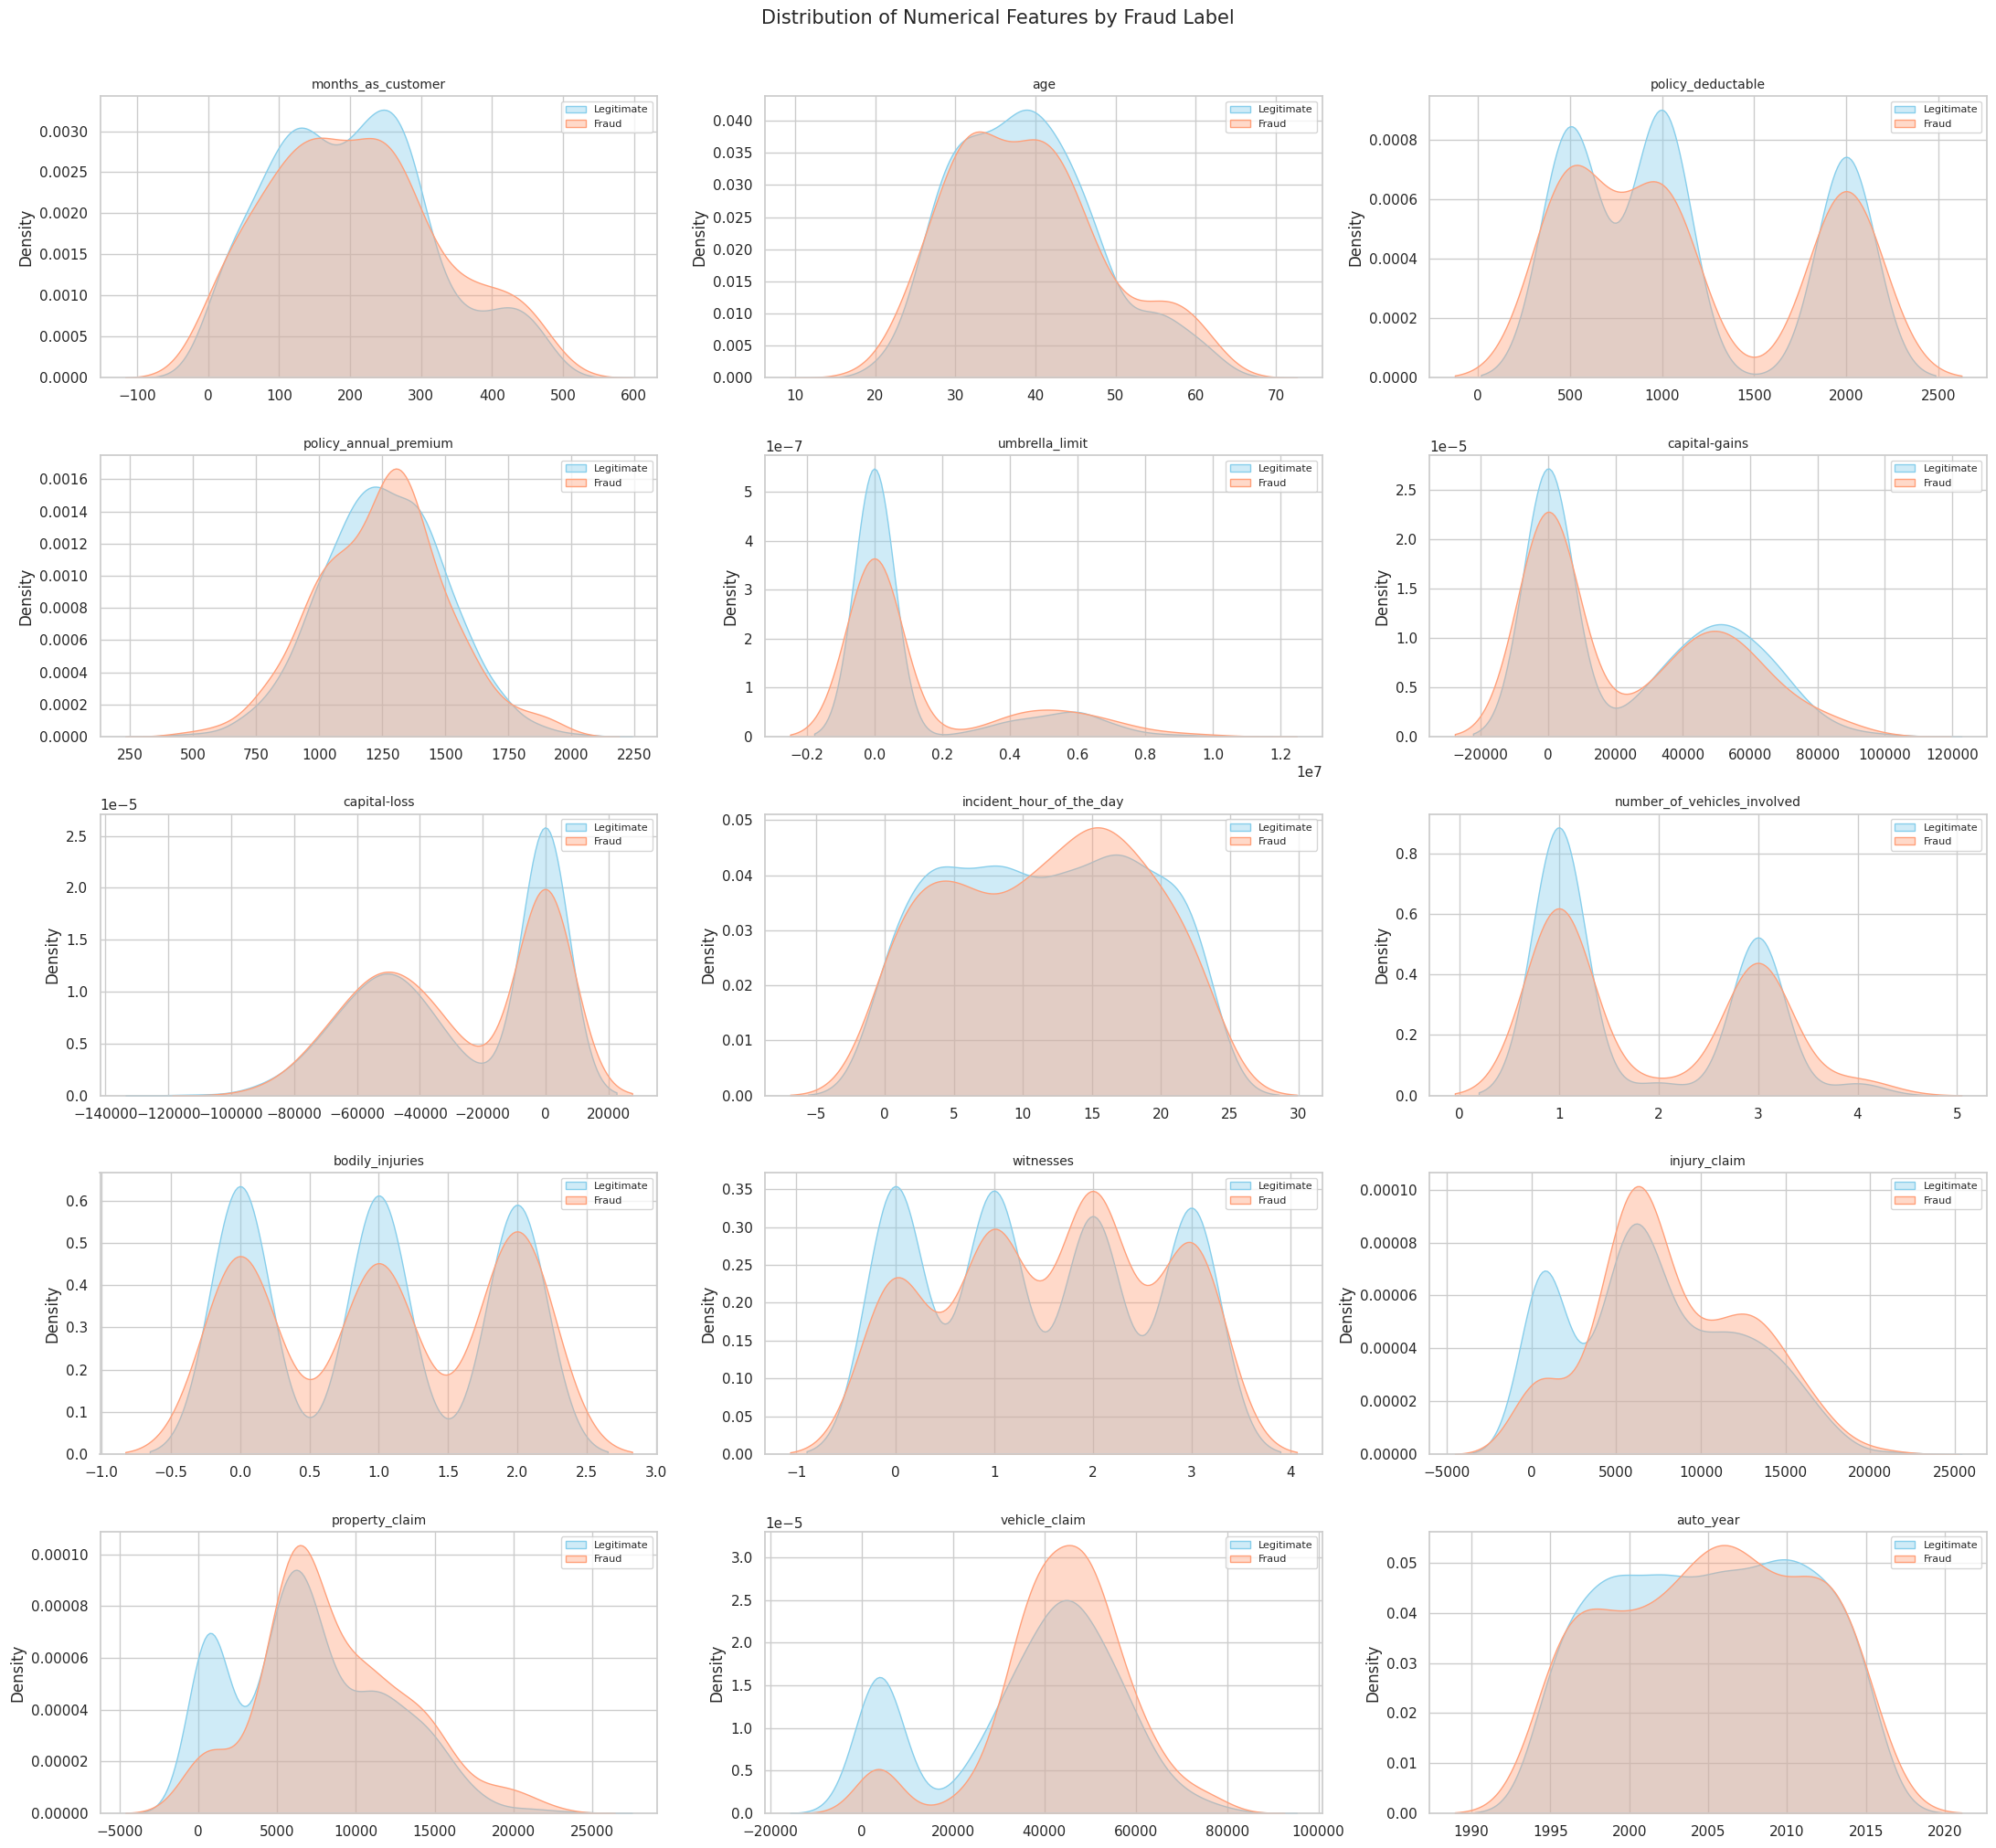

In [26]:
# KDE distributions split by fraud label
num_features = num_infos[~num_infos['columns'].isin(
    ('fraud_reported_bin', 'policy_bind_date', 'incident_date')
)]['columns'].tolist()

n = len(num_features)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axs = plt.subplots(nrows, ncols, figsize=(22, nrows * 4))
axs = axs.flatten()

for i, col in enumerate(num_features):
    for label, color, name in [(0, 'skyblue', 'Legitimate'), (1, 'lightsalmon', 'Fraud')]:
        sns.kdeplot(df[df['fraud_reported_bin'] == label][col], ax=axs[i],
                    fill=True, alpha=0.4, color=color, label=name)
    axs[i].set_title(col, fontsize=10)
    axs[i].legend(fontsize=8)
    axs[i].set_xlabel('')

for j in range(i + 1, len(axs)):
    axs[j].set_visible(False)

plt.suptitle('Distribution of Numerical Features by Fraud Label', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

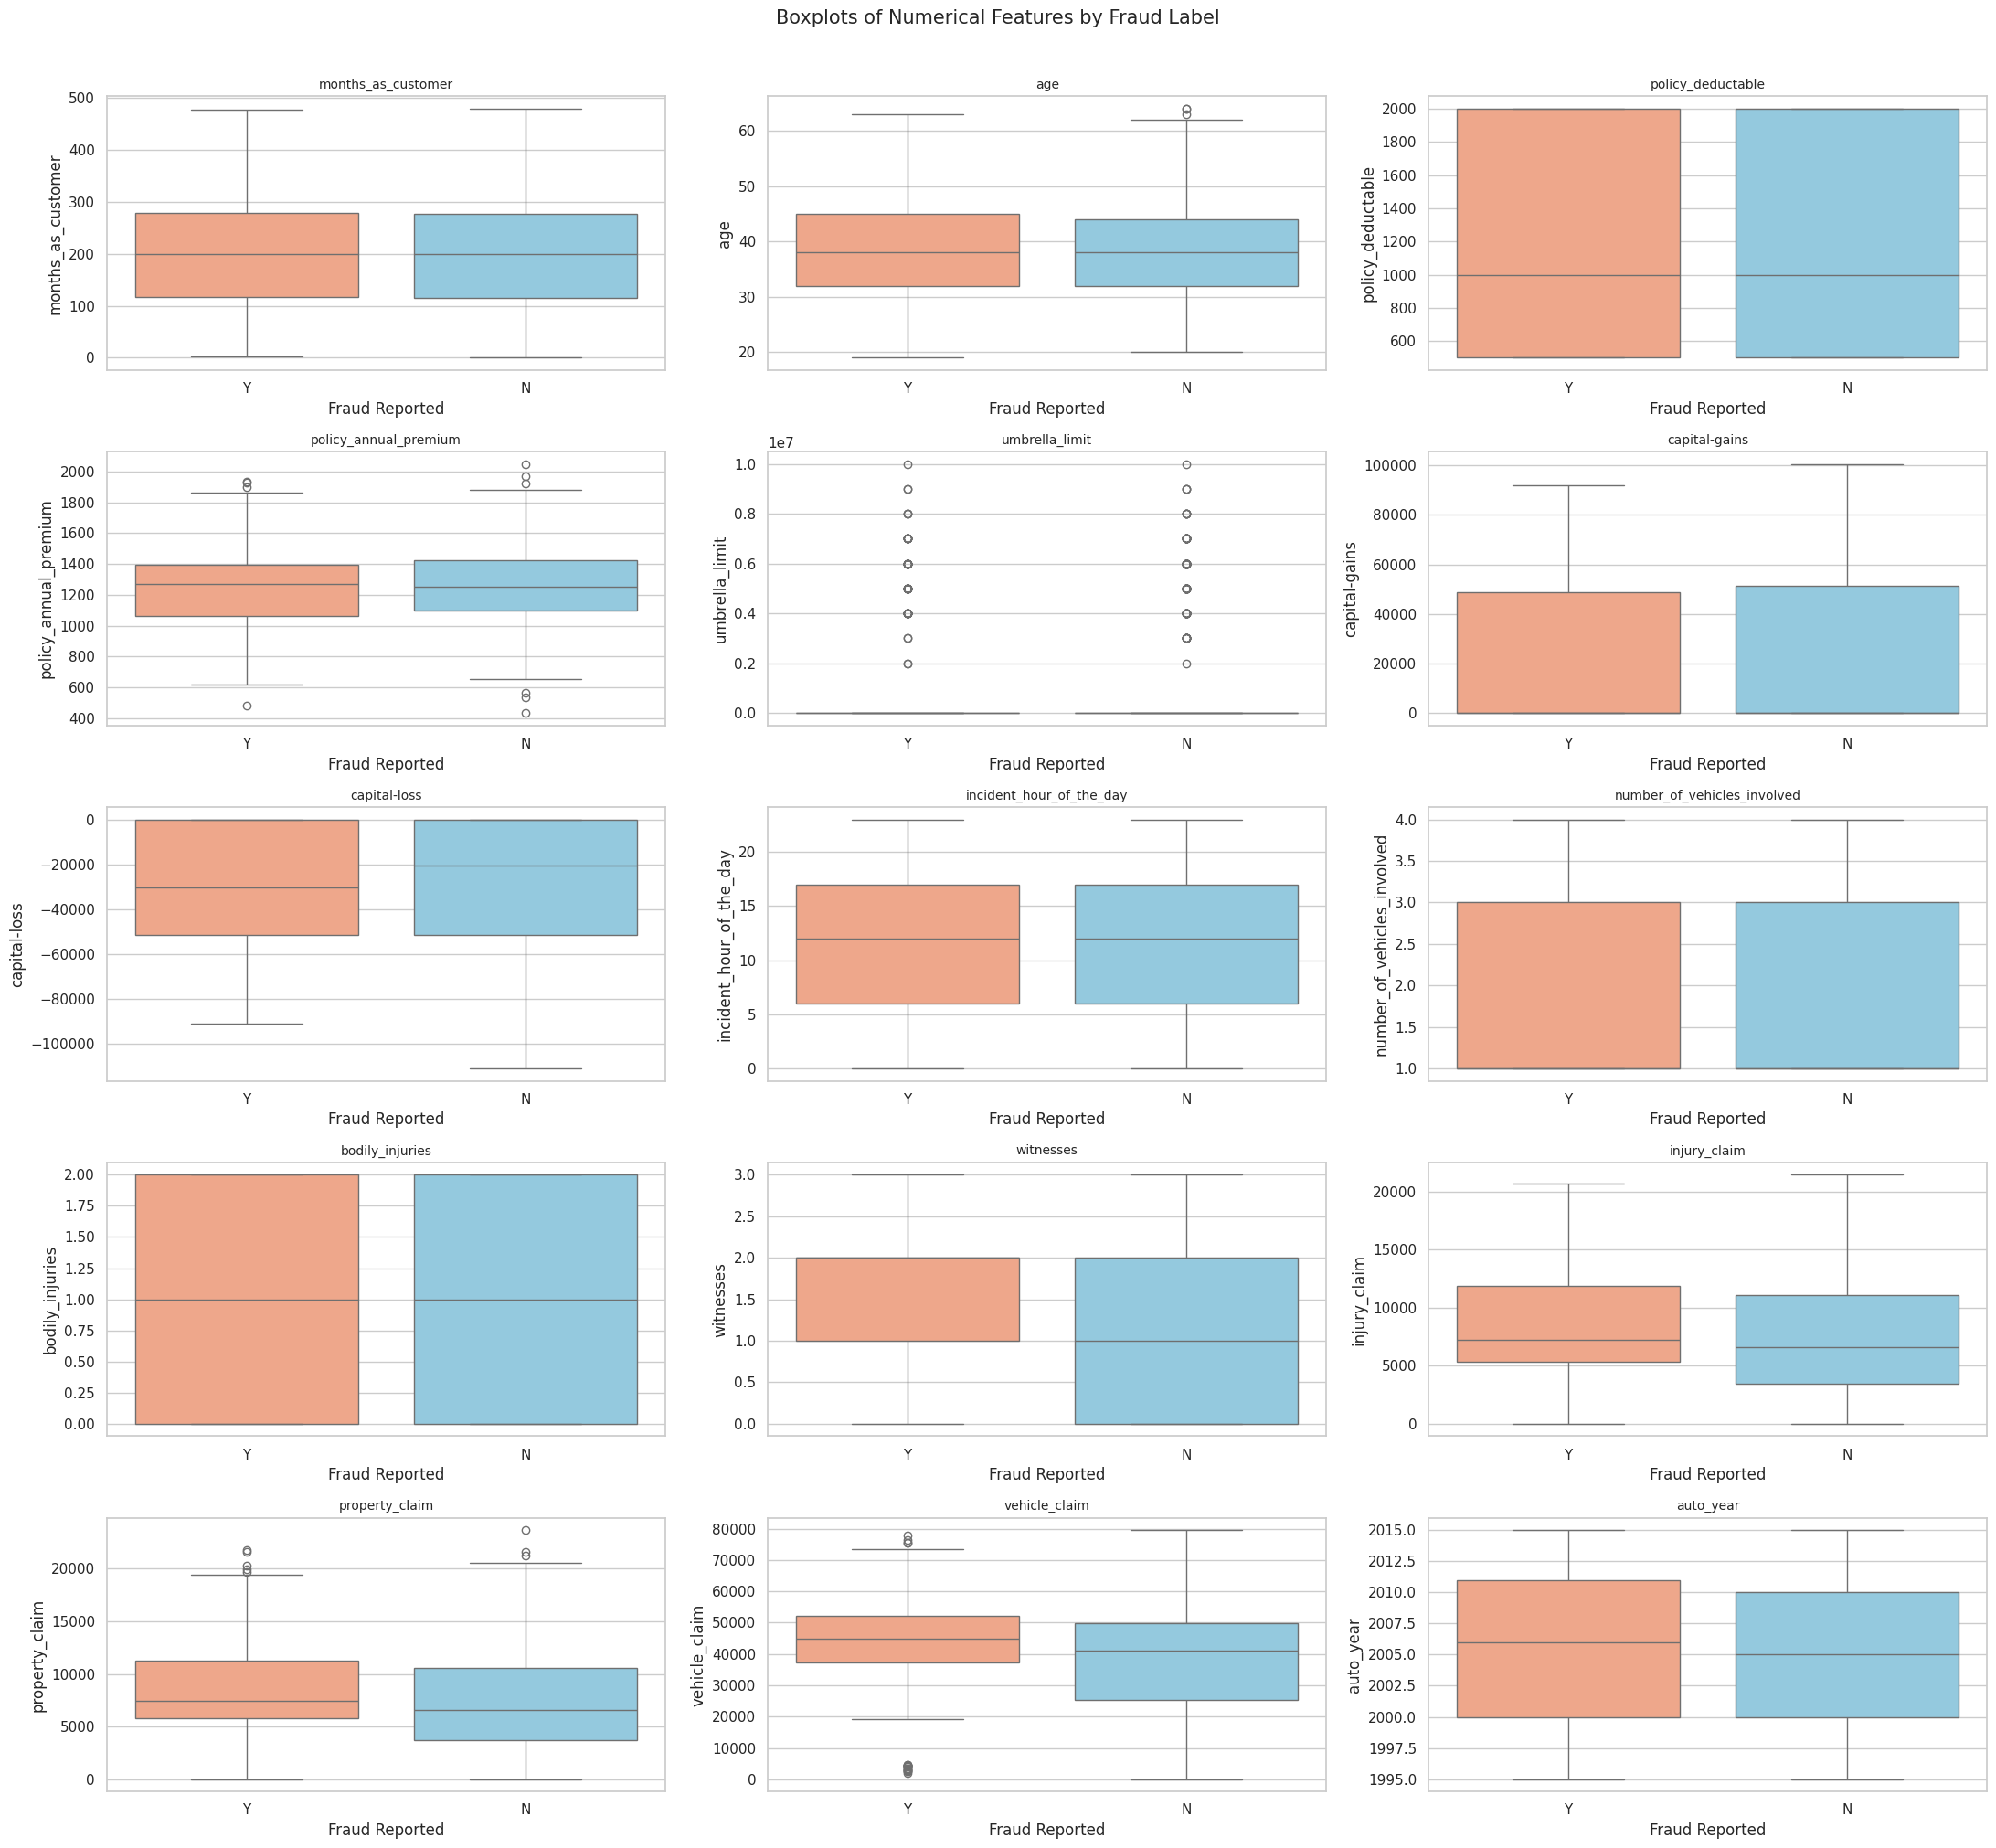

In [27]:
# Boxplots to spot distributional differences and outliers
fig, axs = plt.subplots(nrows, ncols, figsize=(22, nrows * 4))
axs = axs.flatten()

for i, col in enumerate(num_features):
    sns.boxplot(
        data=df, x='fraud_reported', y=col, ax=axs[i],
        palette={'N': 'skyblue', 'Y': 'lightsalmon'}, hue='fraud_reported'
    )
    axs[i].set_title(col, fontsize=10)
    axs[i].set_xlabel('Fraud Reported')

for j in range(i + 1, len(axs)):
    axs[j].set_visible(False)

plt.suptitle('Boxplots of Numerical Features by Fraud Label', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Mean comparison of fraud vs legitimate
mean_comparison = df.groupby('fraud_reported_bin')[num_features].mean().T
mean_comparison.columns = ['Legitimate', 'Fraud']
mean_comparison['Difference %'] = ((mean_comparison['Fraud'] - mean_comparison['Legitimate'])
                                    / mean_comparison['Legitimate'] * 100).round(1)
mean_comparison.sort_values('Difference %', ascending=False)

,Legitimate,Fraud,Difference %
umbrella_limit,1.025232e+06,1.336032e+06,30.3
property_claim,7.018884e+03,8.560121e+03,22.0
vehicle_claim,3.609049e+04,4.353364e+04,20.6
injury_claim,7.179230e+03,8.208340e+03,14.3
witnesses,1.455511e+00,1.582996e+00,8.8
number_of_vehicles_involved,1.808765e+00,1.931174e+00,6.8
bodily_injuries,9.760956e-01,1.040486e+00,6.6
capital-loss,-2.655458e+04,-2.752267e+04,3.6
months_as_customer,2.026003e+02,2.080810e+02,2.7
policy_deductable,1.130810e+03,1.151822e+03,1.9


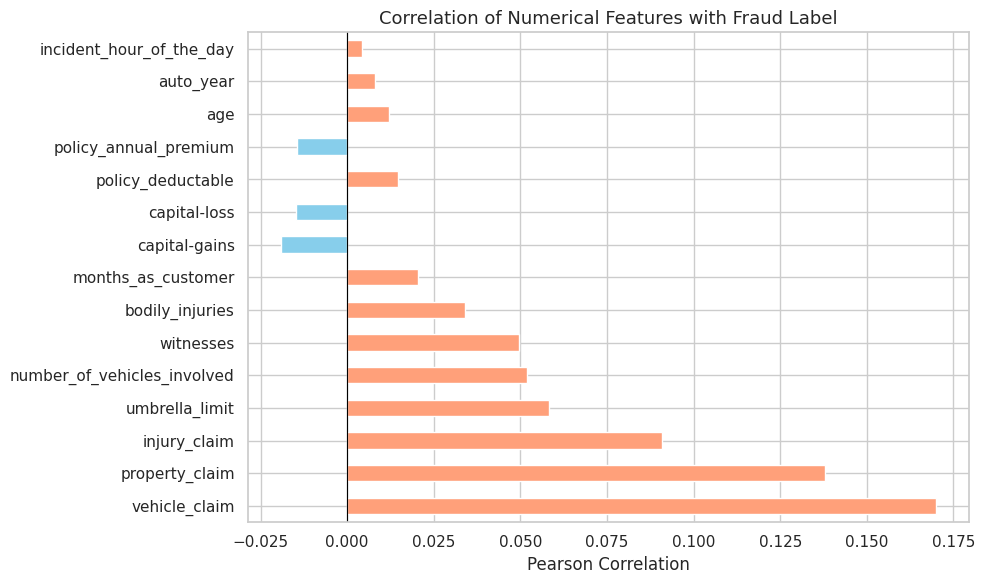

vehicle_claim                  0.170049
property_claim                 0.137835
injury_claim                   0.090975
umbrella_limit                 0.058390
number_of_vehicles_involved    0.051839
witnesses                      0.049497
bodily_injuries                0.033877
months_as_customer             0.020544
capital-gains                 -0.019173
capital-loss                  -0.014863
policy_deductable              0.014817
policy_annual_premium         -0.014480
age                            0.012143
auto_year                      0.007928
incident_hour_of_the_day       0.004316
Name: fraud_reported_bin, dtype: float64


In [28]:
# Correlation of numerical features with fraud_reported
corr_with_target = df[num_features + ['fraud_reported_bin']].corr()['fraud_reported_bin'].drop('fraud_reported_bin')
corr_with_target = corr_with_target.sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 6))
corr_with_target.plot(kind='barh', color=['lightsalmon' if x > 0 else 'skyblue' for x in corr_with_target])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlation of Numerical Features with Fraud Label', fontsize=13)
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()
print(corr_with_target)

In [29]:
# Outlier detection using IQR
def flag_outliers(df, col, N=1.5):
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - N * iqr, q3 + N * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return len(outliers), lower, upper

outlier_summary = []
for col in ['property_claim', 'vehicle_claim', 'policy_annual_premium', 'age']:
    count, lo, hi = flag_outliers(df, col)
    outlier_summary.append({'feature': col, 'outlier_count': count, 'lower_bound': round(lo,2), 'upper_bound': round(hi,2)})

pd.DataFrame(outlier_summary)

,feature,outlier_count,lower_bound,upper_bound
0,property_claim,6,-5215.00,20545.00
1,vehicle_claim,0,-502.50,81617.50
2,policy_annual_premium,9,600.48,1904.83
3,age,4,14.00,62.00


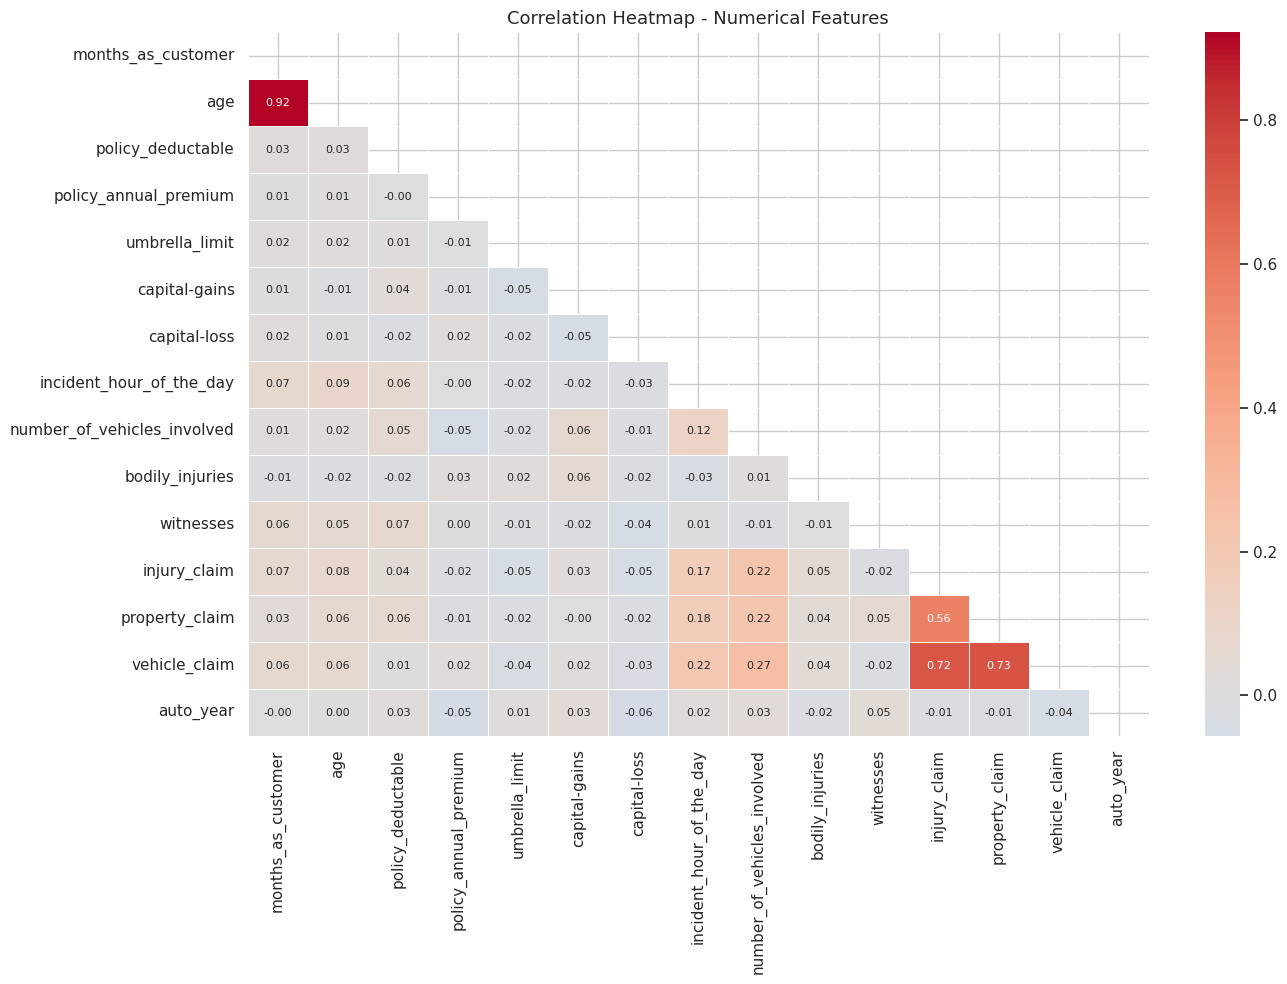

In [30]:
# Correlation heatmap for numerical features
plt.figure(figsize=(14, 10))
corr_matrix = df[num_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Heatmap - Numerical Features', fontsize=13)
plt.tight_layout()
plt.show()

**Observations — Numerical Variables**

| Feature | Insight |
|---|---|
| `vehicle_claim` / `property_claim` | Fraudulent claims are significantly higher on average |
| `injury_claim` | Moderate signal |
| `capital-gains` / `capital-loss`/ `umbrella_limit` | Near-zero for most clients; high values may be informative |
| `incident_hour_of_the_day` | No signal but grouping may be useful |

**NB:** `injury_claim`, `property_claim`, and `vehicle_claim` are correlated so claim ratios may be more informative than raw values.

**Next step: `02_Feature_Engineering.ipynb`** where we'll encode categoricals, create derived features, handle outliers, build feature sets for modelling.